# EDA · interconexiones, congestión y formación del precio

Tercera pieza descriptiva, después de `04_eda_balance_sistema`. Aquí el foco está en las dos
cosas que explican por qué el precio español es el que es: **con quién está conectado el sistema
y cuándo esa conexión se satura**, y **qué tecnología queda marcando el precio en la casación**.

## La advertencia que no se puede repetir lo suficiente

Este notebook usa precios de países vecinos y programas de mercado. Todas las zonas SDAC se
casan **a la vez, a las 12:00 de D**, y se publican hacia las 12:45. Eso significa que:

- el precio francés de D+1 **no existe** cuando hay que predecir el español de D+1;
- el PDBC de D+1 sale de **la misma casación** que el precio, así que usarlo es circular;
- la diferencia de precios entre zonas, que es como se mide la congestión, hereda las dos
  restricciones anteriores.

Nada de esto invalida el análisis: lo sitúa. Es material de capítulo, y las pocas piezas que sí
pueden convertirse en feature (siempre con lag de D) están marcadas una por una.

## Índice

| Fig. | Contenido | Requiere |
|---|---|---|
| M.1 | Evolución anual de los intercambios por frontera | `load_inter` |
| M.2 | Capacidad de intercambio (NTC) y saldo neto | `load_inter` (NTC) |
| M.3 | Uso de la capacidad de intercambio (%) | `load_inter` (NTC) |
| M.4 | Horas con y sin congestión frente al diferencial de precios | precio ES + precio FR/PT |
| M.5 | Generación renovable en GWh frente al precio | generación + `spot_price` |
| M.6 | Porcentaje de renovable frente al precio | generación + `spot_price` |
| M.7 | Picos y valles: máximos y mínimos por hora y día de la semana | demanda + `spot_price` |
| M.8 | Evolución de los precios máximos y mínimos diarios | `spot_price` |
| M.9 | PDBC frente a PBF: cuánto pesan los bilaterales | `esios_pdbc_gen`, `esios_pbf_*` |
| M.10 | Estructura de generación en la casación, precio y gas | generación + precio + `commodities` |

---
## 0 · Carga y resolución de columnas

In [13]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

%matplotlib inline
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

TZ = "Europe/Madrid"
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
BRONZE_DIR = RAIZ / "data" / "bronze"
# Ya no hace falta el dataset externo de Ember: spot_price trae 12 zonas de precio.

plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titlesize": 12,
})
MILES = FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))

OMITIDOS = []

def pick(df, *cands):
    for c in cands:
        if c is not None and c in df.columns:
            return c
    return None

def falta(bloque, **cols):
    ausentes = [k for k, v in cols.items() if v is None]
    if ausentes:
        OMITIDOS.append(f"{bloque}: faltan {ausentes}")
        print(f"OMITIDO -- {bloque}: faltan {ausentes}")
        return True
    return False

In [14]:
df = pd.read_parquet(BRONZE_DIR / "bronze_unificado.parquet")
df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True)

dup = df["ts_utc"].duplicated().sum()
assert dup == 0, (
    f"{dup:,} filas con ts_utc repetido: el parquet sigue duplicado. Todos los GWh de este "
    f"notebook saldrían multiplicados. Corregir el grain y regenerar antes de seguir."
)

df["ts_local"] = df["ts_utc"].dt.tz_convert(TZ)
df["anio"] = df["ts_local"].dt.year
df["mes_p"] = df["ts_local"].dt.to_period("M")
df["dia"] = df["ts_local"].dt.date
df["hora"] = df["ts_local"].dt.hour
df["dow"] = df["ts_local"].dt.dayofweek
print(f"{len(df):,} horas · {df['ts_utc'].min()} -> {df['ts_utc'].max()}")

# --- columnas clave, resueltas una vez
SPOT = pick(df, "spot_es_omie", "es_omie", "spot_es_esios", "spot_es_entsoe")
DEM  = pick(df, "load_inter_entsoe_load", "ent_li_actual_load_mw", "load_inter_ree_load")
EOL  = pick(df, "gen_ent_gwind", "entsoe_wind_mw", "esios_gen_ree_gwind_mw")
FV   = pick(df, "gen_c_gsolar", "calc_solar_fv_mw", "entsoe_solar_mw")
HID  = pick(df, "gen_c_ghydrodispatch", "calc_hydro_dispatch_mw")
GAS  = pick(df, "tp_ttf_cierre", "commodities_gas_ttf_m1", "commodities_gas_mibgas")

# Saldos por frontera (signo positivo = importación) y sus NTC.
FRONTERAS = {
    # `load_inter` da el saldo neto y las NTC; `entsoe_load_inter` añade los flujos
    # DIRECCIONALES (import y export por separado), que son mejores para medir saturación.
    "Francia":   {"saldo": ["load_inter_ree_netflow_fr", "ent_li_net_flow_fr_mw"],
                  "ntc_imp": ["load_inter_ree_ntc_impfr", "ent_li_ntc_imp_fr_mw"],
                  "ntc_exp": ["load_inter_ree_ntc_expfr", "ent_li_ntc_exp_fr_mw"],
                  "flujo_imp": ["ent_li_flow_fr_es_mw"], "flujo_exp": ["ent_li_flow_es_fr_mw"]},
    "Portugal":  {"saldo": ["load_inter_ree_netflow_pt", "ent_li_net_flow_pt_mw"],
                  "ntc_imp": ["load_inter_ree_ntc_imppt", "ent_li_ntc_imp_pt_mw"],
                  "ntc_exp": ["load_inter_ree_ntc_exppt", "ent_li_ntc_exp_pt_mw"],
                  "flujo_imp": ["ent_li_flow_pt_es_mw"], "flujo_exp": ["ent_li_flow_es_pt_mw"]},
    "Marruecos": {"saldo": ["load_inter_ree_netflow_ma"],
                  "ntc_imp": ["load_inter_ree_ntc_impma"], "ntc_exp": ["load_inter_ree_ntc_expma"],
                  "flujo_imp": [], "flujo_exp": []},
}
INTER = {}
for pais, c in FRONTERAS.items():
    INTER[pais] = {k: pick(df, *v) for k, v in c.items()}
print("\nColumnas resueltas:")
for k, v in {"precio": SPOT, "demanda": DEM, "eólica": EOL, "solar": FV, "hidráulica": HID, "gas": GAS}.items():
    print(f"  {k:12s} -> {v}")
print("\nInterconexiones:")
for p, c in INTER.items():
    print(f"  {p:11s} saldo={c['saldo']}  ntc_imp={c.get('ntc_imp')}  ntc_exp={c.get('ntc_exp')}")

58,319 horas · 2019-12-31 23:00:00+00:00 -> 2026-08-26 21:00:00+00:00

Columnas resueltas:
  precio       -> spot_es_omie
  demanda      -> load_inter_entsoe_load
  eólica       -> entsoe_wind_mw
  solar        -> calc_solar_fv_mw
  hidráulica   -> calc_hydro_dispatch_mw
  gas          -> commodities_gas_ttf_m1

Interconexiones:
  Francia     saldo=load_inter_ree_netflow_fr  ntc_imp=load_inter_ree_ntc_impfr  ntc_exp=load_inter_ree_ntc_expfr
  Portugal    saldo=load_inter_ree_netflow_pt  ntc_imp=load_inter_ree_ntc_imppt  ntc_exp=load_inter_ree_ntc_exppt
  Marruecos   saldo=load_inter_ree_netflow_ma  ntc_imp=load_inter_ree_ntc_impma  ntc_exp=load_inter_ree_ntc_expma


C:\Users\torgi\AppData\Local\Temp\ipykernel_30080\247024366.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["mes_p"] = df["ts_local"].dt.to_period("M")


**Convención de signo, que conviene fijar antes de dibujar nada.** En las series de REE el
saldo positivo es **importación** (energía que entra al sistema español). Si al mirar la primera
figura la exportación a Portugal sale con el signo cambiado respecto a lo que sabemos del
sistema —España exporta a Portugal la mayor parte del tiempo—, hay que invertir el signo aquí y
no en cada figura por separado.

In [15]:
# Si el signo viniera invertido en la fuente, cambiar esto a -1 (una sola vez, aquí).
SIGNO = 1

for pais, c in INTER.items():
    if c["saldo"]:
        s = df[c["saldo"]] * SIGNO
        print(f"{pais:11s} media {s.mean():>9,.0f} MW · "
              f"horas importando {(s > 0).mean()*100:>5.1f}% · exportando {(s < 0).mean()*100:>5.1f}%")

Francia     media        62 MW · horas importando  49.7% · exportando  50.2%
Portugal    media      -904 MW · horas importando  28.3% · exportando  71.7%
Marruecos   media      -219 MW · horas importando  30.8% · exportando  68.6%


---
## M.1 · Evolución anual de los intercambios internacionales

**Contexto.** La figura equivalente del informe de REE: importación y exportación acumuladas por
frontera, con el saldo neto superpuesto.

**Consecuencia.** Un sistema exportador neto en horas de sol y importador en horas punta usa la
interconexión como una batería lenta. El signo del saldo por año dice si España está vendiendo
excedente renovable o comprando respaldo, y eso condiciona el precio de las horas extremas.

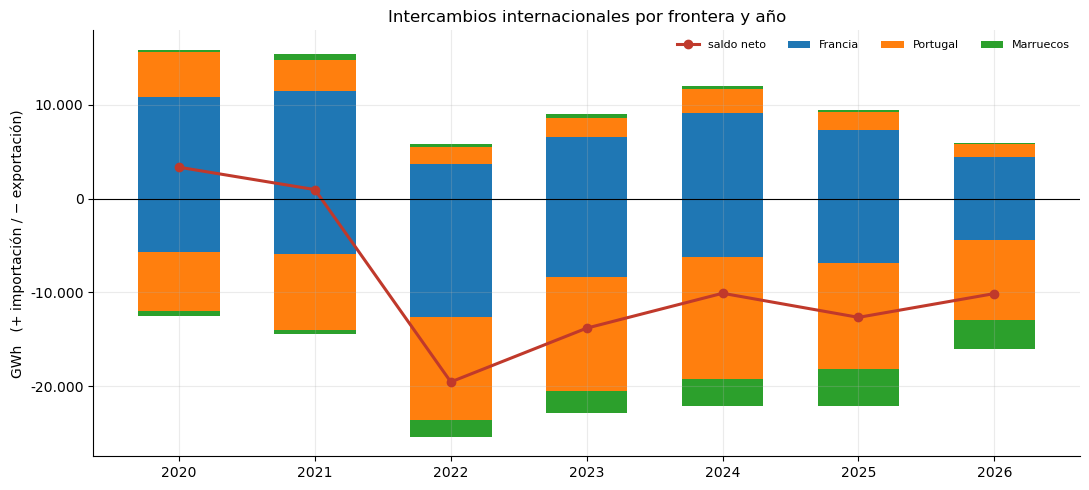

,Francia import,Francia export,Portugal import,Portugal export,Marruecos import,Marruecos export,saldo
anio,,,,,,,
2020,10870.0,-5721.0,4721.0,-6219.0,298.0,-593.0,3355.0
2021,11496.0,-5935.0,3304.0,-8080.0,593.0,-411.0,967.0
2022,3723.0,-12568.0,1772.0,-11033.0,370.0,-1805.0,-19542.0
2023,6617.0,-8312.0,1981.0,-12233.0,415.0,-2273.0,-13806.0
2024,9158.0,-6216.0,2559.0,-13047.0,314.0,-2855.0,-10087.0
2025,7273.0,-6873.0,1997.0,-11300.0,168.0,-3921.0,-12657.0
2026,4455.0,-4377.0,1382.0,-8536.0,63.0,-3106.0,-10119.0



Los años parciales no son comparables en volumen: mirar el signo y el reparto entre fronteras, no la altura de la barra.


In [16]:
filas = []
for pais, c in INTER.items():
    if not c["saldo"]:
        continue
    s = (df[["anio", c["saldo"]]].dropna()).copy()
    s["v"] = s[c["saldo"]] * SIGNO
    g = s.groupby("anio")["v"]
    filas.append(pd.DataFrame({
        f"{pais} import": g.apply(lambda x: x[x > 0].sum() / 1000),
        f"{pais} export": g.apply(lambda x: x[x < 0].sum() / 1000),
    }))

if not filas:
    OMITIDOS.append("M.1: sin columnas de saldo")
    print("OMITIDO -- sin columnas de saldo por frontera")
else:
    inter = pd.concat(filas, axis=1)
    imp = inter[[c for c in inter.columns if c.endswith("import")]]
    exp = inter[[c for c in inter.columns if c.endswith("export")]]
    saldo = imp.sum(axis=1) + exp.sum(axis=1)

    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(inter))
    abajo_i = np.zeros(len(inter)); abajo_e = np.zeros(len(inter))
    for col in imp.columns:
        ax.bar(x, imp[col], bottom=abajo_i, label=col.replace(" import", ""), width=0.6)
        abajo_i += imp[col].values
    for i, col in enumerate(exp.columns):
        ax.bar(x, exp[col], bottom=abajo_e, width=0.6,
               color=ax.containers[i][0].get_facecolor())
        abajo_e += exp[col].values
    ax.plot(x, saldo.values, color="#c0392b", lw=2.2, marker="o", label="saldo neto")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x, inter.index.astype(str))
    ax.set_ylabel("GWh   (+ importación / − exportación)"); ax.yaxis.set_major_formatter(MILES)
    ax.set_title("Intercambios internacionales por frontera y año")
    ax.legend(frameon=False, ncol=5, fontsize=8)
    plt.tight_layout(); plt.show()

    display(inter.round(0).assign(saldo=saldo.round(0)))
    print("\nLos años parciales no son comparables en volumen: mirar el signo y el reparto "
          "entre fronteras, no la altura de la barra.")

---
## M.2 · Capacidad de intercambio y saldo neto

**Contexto.** La NTC es la capacidad comercial máxima en cada sentido, y varía hora a hora
según el estado de la red. El saldo real se mueve dentro de esa banda; cuando la toca, la
interconexión está saturada.

**Nota heredada del EDA de bronce:** las NTC de ESIOS son 15-min nativo pero miden **potencia**.
Agregadas con `SUM` se inflan ×4 exacto, y esa exactitud es la firma que permite detectarlo. Si
los valores de esta figura salen cuatro veces mayores de lo razonable (~×4 sobre los ~2.800 MW
típicos de la interconexión con Francia), el problema está en la ingesta, no aquí.

Año representado: 2026


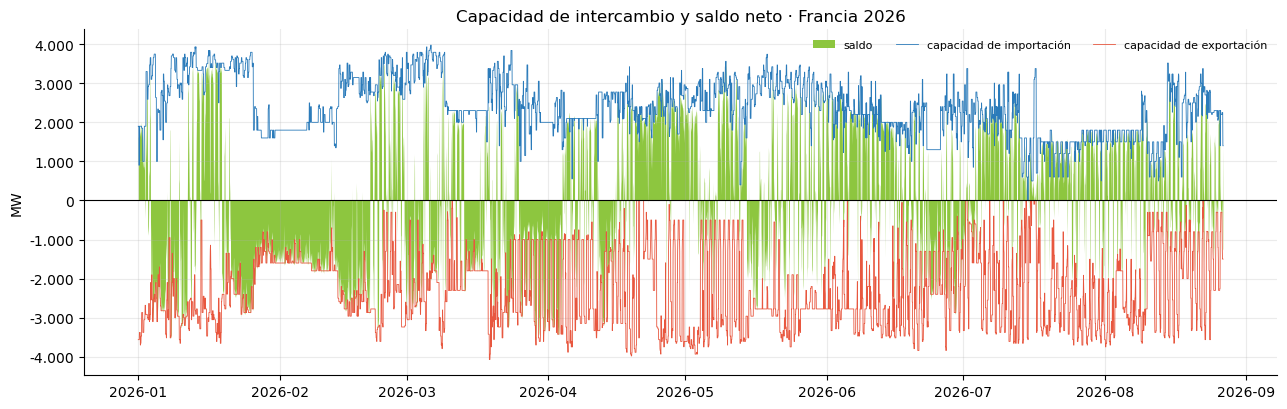

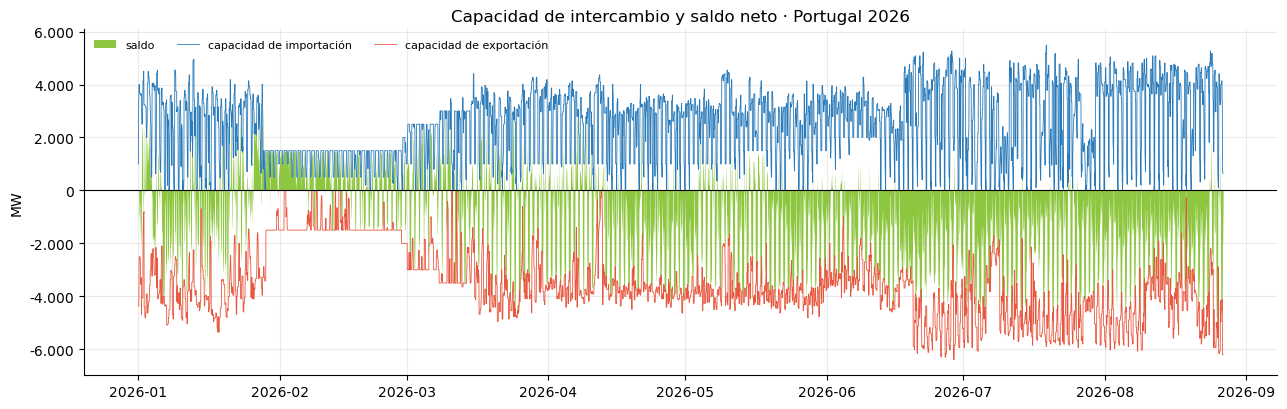

In [17]:
ANIO = df["anio"].max() if df["anio"].max() in df["anio"].value_counts()[lambda s: s > 4000].index else df["anio"].max() - 1
print(f"Año representado: {ANIO}")

for pais in ["Francia", "Portugal"]:
    c = INTER.get(pais, {})
    if not (c.get("saldo") and c.get("ntc_imp")):
        OMITIDOS.append(f"M.2 {pais}: sin saldo o sin NTC")
        print(f"OMITIDO -- {pais}: saldo={c.get('saldo')} ntc_imp={c.get('ntc_imp')}")
        continue
    d = df[df["anio"] == ANIO][["ts_local", c["saldo"], c["ntc_imp"]] +
                               ([c["ntc_exp"]] if c.get("ntc_exp") else [])].dropna(subset=[c["saldo"]])

    fig, ax = plt.subplots(figsize=(13, 4.2))
    ax.fill_between(d["ts_local"], d[c["saldo"]] * SIGNO, 0, color="#8dc63f", lw=0, label="saldo")
    ax.plot(d["ts_local"], d[c["ntc_imp"]], color="#2b7bba", lw=0.6, label="capacidad de importación")
    if c.get("ntc_exp"):
        ax.plot(d["ts_local"], -d[c["ntc_exp"]].abs(), color="#e8573f", lw=0.6,
                label="capacidad de exportación")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("MW"); ax.yaxis.set_major_formatter(MILES)
    ax.set_title(f"Capacidad de intercambio y saldo neto · {pais} {ANIO}")
    ax.legend(frameon=False, ncol=3, fontsize=8)
    plt.tight_layout(); plt.show()

## M.3 · Uso de la capacidad de intercambio

**Contexto.** El porcentaje de la NTC que se está usando en cada hora, separando importación de
exportación. En el informe de REE es un gráfico denso de barras verticales; el valor está en ver
**cuántas horas se pega al 100 %**, que son las horas en que la interconexión limita.

**Consecuencia.** Las horas al 100 % son exactamente las horas en que el precio español puede
desacoplarse del francés. Es la conexión entre esta figura y la siguiente.


Francia:


media    p90  horas_al_100
anio sentido                                
2020 exportación   75.8  102.0          1212
     importación   80.5  100.6          1624
2021 exportación   77.6  101.7           952
     importación   79.0   99.2           610
2022 exportación   88.6  102.8          2333
     importación   68.8  100.5           346
2023 exportación   82.6  101.7          1155
     importación   76.8  100.5           695
2024 exportación   76.9  101.4           777
     importación   78.3  100.6           987
2025 exportación   72.4  100.1           571
     importación   74.1   99.7           649
2026 exportación   74.2  101.1           563
     importación   71.2   99.2           304

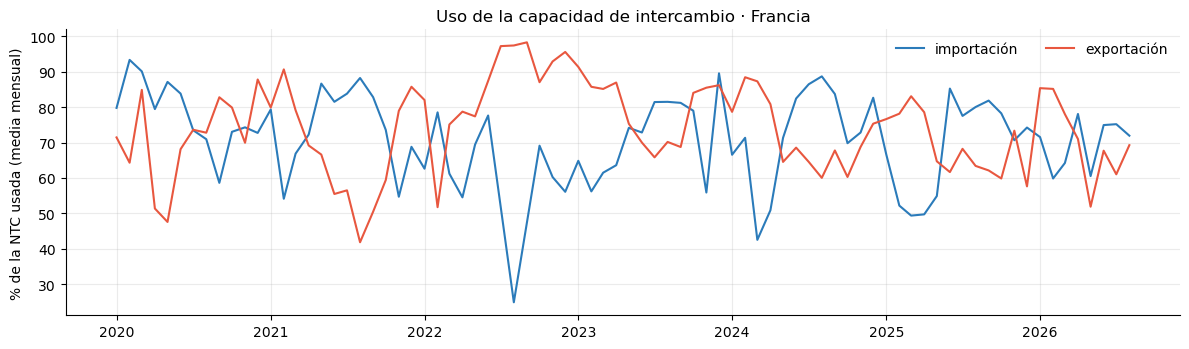


Portugal:


media   p90  horas_al_100
anio sentido                               
2020 exportación   43.4  88.6           245
     importación   44.2  94.4           188
2021 exportación   36.9  73.0           102
     importación   36.6  81.0            13
2022 exportación   45.3  85.9           251
     importación   33.6  72.0            10
2023 exportación   53.3  97.7           553
     importación   41.3  85.9            37
2024 exportación   56.6  94.3           317
     importación   49.6  93.9            94
2025 exportación   53.7  96.8           406
     importación   41.1  88.5            57
2026 exportación   56.6  99.4           479
     importación   60.2  99.5           227

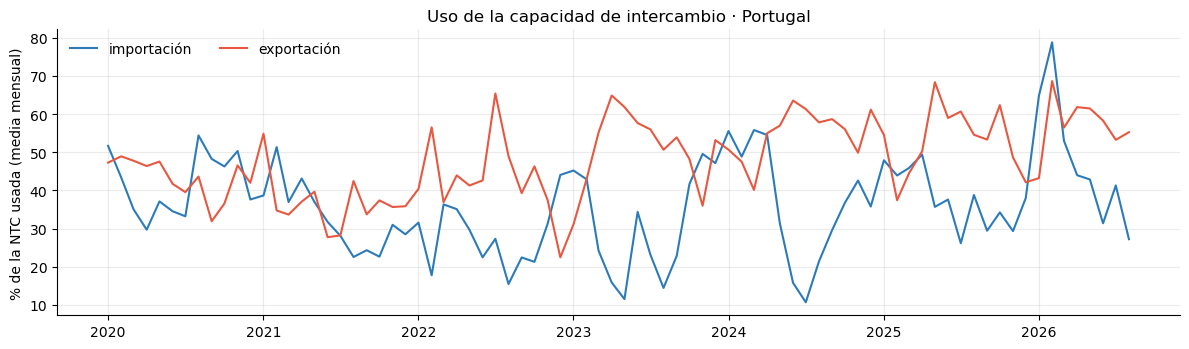

In [18]:
for pais in ["Francia", "Portugal"]:
    c = INTER.get(pais, {})
    if not (c.get("saldo") and c.get("ntc_imp")):
        continue
    d = df[["ts_local", "anio", "mes_p", c["saldo"], c["ntc_imp"]] +
           ([c["ntc_exp"]] if c.get("ntc_exp") else [])].dropna(subset=[c["saldo"], c["ntc_imp"]]).copy()
    v = d[c["saldo"]] * SIGNO
    ntc_e = d[c["ntc_exp"]].abs() if c.get("ntc_exp") else d[c["ntc_imp"]]

    d["uso_pct"] = np.where(v > 0, v / d[c["ntc_imp"]].replace(0, np.nan) * 100,
                            v.abs() / ntc_e.replace(0, np.nan) * 100)
    d["sentido"] = np.where(v > 0, "importación", "exportación")
    d["uso_pct"] = d["uso_pct"].clip(0, 120)

    resumen = d.groupby(["anio", "sentido"])["uso_pct"].agg(
        media="mean", p90=lambda s: s.quantile(0.9),
        horas_al_100=lambda s: (s >= 99).sum()).round(1)
    print(f"\n{pais}:")
    display(resumen)

    fig, ax = plt.subplots(figsize=(12, 3.6))
    for sent, color in [("importación", "#2b7bba"), ("exportación", "#e8573f")]:
        sub = d[d["sentido"] == sent].groupby("mes_p")["uso_pct"].mean()
        ax.plot(sub.index.to_timestamp(), sub.values, label=sent, color=color)
    ax.set_ylabel("% de la NTC usada (media mensual)")
    ax.set_title(f"Uso de la capacidad de intercambio · {pais}")
    ax.legend(frameon=False, ncol=2)
    plt.tight_layout(); plt.show()

---
## M.4 · Congestión y diferencial de precios

**Contexto.** En un mercado acoplado, si la interconexión no está saturada los precios de las
dos zonas **convergen**. Cuando difieren, es porque la capacidad no alcanza para arbitrar la
diferencia: eso es congestión, y su signo indica el sentido.

**Cómo se mide aquí.** No hace falta un dato de congestión: se deduce del propio precio. Se
considera hora sin congestión aquella en que la diferencia absoluta entre el precio español y
el vecino es menor que un umbral pequeño (0,01 EUR/MWh por defecto, para absorber redondeos).

**Consecuencia.** El porcentaje de horas desacopladas con Portugal decide si el perímetro
peninsular puede tratarse como una sola zona de precio —supuesto que el TFM asume— o si es una
simplificación que hay que declarar. Con Francia, mide cuánta información del precio francés es
realmente independiente.

**Y la advertencia de siempre:** el precio francés de D+1 se casa a la vez que el español. Esta
figura explica, no predice.

In [19]:
# Las zonas vecinas están en la propia tabla spot_price: 12 países. Ya no hace falta
# el dataset externo de Ember, y además cubren exactamente el mismo período que el target.
VECINOS = {}
for iso, etq in [("pt_omie", "Portugal"), ("fr_entsoe", "Francia"),
                 ("de_lu_entsoe", "Alemania-Lux"), ("it_nord_entsoe", "Italia norte"),
                 ("ch_entsoe", "Suiza"), ("be_entsoe", "Bélgica"),
                 ("nl_entsoe", "Países Bajos"), ("at_entsoe", "Austria"),
                 ("pl_entsoe", "Polonia"), ("cz_entsoe", "Chequia")]:
    c = pick(df, f"spot_{iso}", iso)
    if c:
        VECINOS[etq] = c

if not SPOT:
    OMITIDOS.append("M.4: spot_price no está en el bronce")
    print("OMITIDO -- falta el precio español. Es el hueco nº 1 del EDA.")
elif not VECINOS:
    OMITIDOS.append("M.4: sin zonas vecinas en spot_price")
    print("OMITIDO -- sin precios de zonas vecinas")
else:
    print(f"{len(VECINOS)} zonas vecinas disponibles: {list(VECINOS)}")
    c = df[[SPOT] + list(VECINOS.values())].corr()[SPOT].drop(SPOT).sort_values(ascending=False)
    display(c.round(4).rename("correlación con ES").to_frame())
    print("Todas CON FUGA para D+1: la casación SDAC es simultánea a las 12:00.")

10 zonas vecinas disponibles: ['Portugal', 'Francia', 'Alemania-Lux', 'Italia norte', 'Suiza', 'Bélgica', 'Países Bajos', 'Austria', 'Polonia', 'Chequia']


,correlación con ES
spot_pt_omie,0.9965
spot_fr_entsoe,0.7050
spot_ch_entsoe,0.6792
spot_be_entsoe,0.6763
spot_nl_entsoe,0.6664
spot_it_nord_entsoe,0.6504
spot_at_entsoe,0.6470
spot_cz_entsoe,0.6264
spot_de_lu_entsoe,0.6166
spot_pl_entsoe,0.5083


Todas CON FUGA para D+1: la casación SDAC es simultánea a las 12:00.


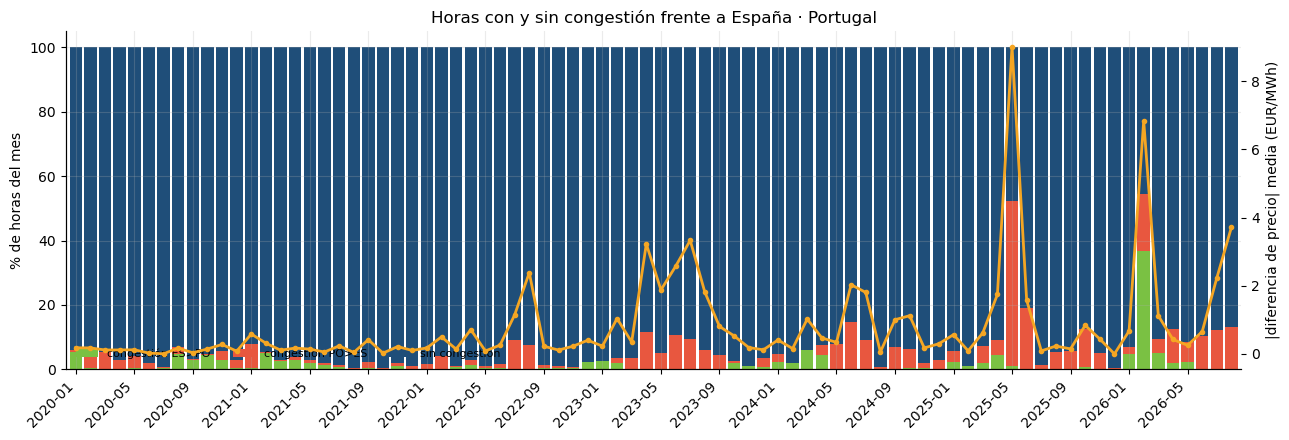


Portugal:


estado,congestión ES>PO,congestión PO>ES,sin congestión,|dif| media
anio,,,,
2020,1.9,2.2,95.9,0.12
2021,1.3,1.3,97.4,0.20
2022,0.5,2.4,97.1,0.53
2023,0.7,4.6,94.7,1.34
2024,1.3,4.6,94.1,0.74
2025,0.9,9.5,89.5,1.29
2026,6.1,9.4,84.5,1.90


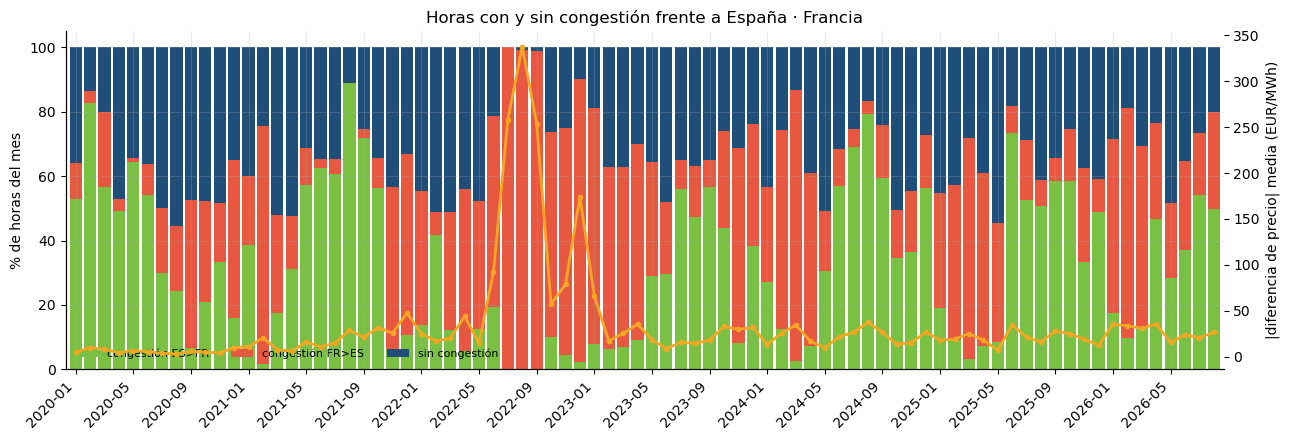


Francia:


estado,congestión ES>FR,congestión FR>ES,sin congestión,|dif| media
anio,,,,
2020,40.7,19.9,39.3,5.85
2021,42.3,22.9,34.8,20.23
2022,9.9,63.4,26.7,115.19
2023,28.5,38.7,32.8,26.32
2024,39.5,27.8,32.7,22.33
2025,35.3,28.3,36.4,20.29
2026,31.8,38.9,29.2,27.72


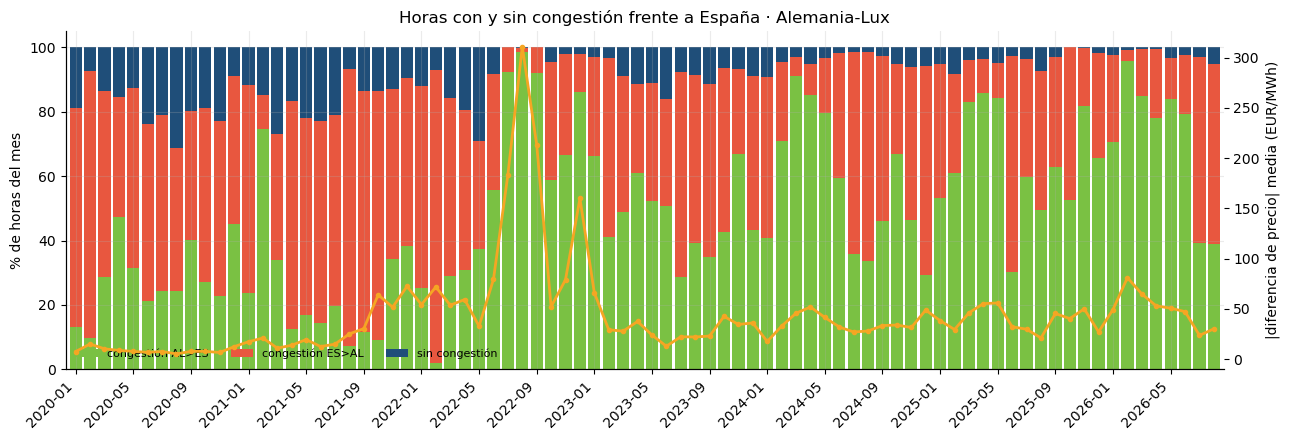


Alemania-Lux:


estado,congestión AL>ES,congestión ES>AL,sin congestión,|dif| media
anio,,,,
2020,28.0,54.1,17.9,8.63
2021,24.3,59.6,16.1,29.59
2022,56.6,35.0,8.4,112.89
2023,48.0,43.3,8.6,31.59
2024,57.0,38.9,4.1,35.37
2025,64.2,32.2,3.7,39.28
2026,71.7,26.2,2.2,50.04


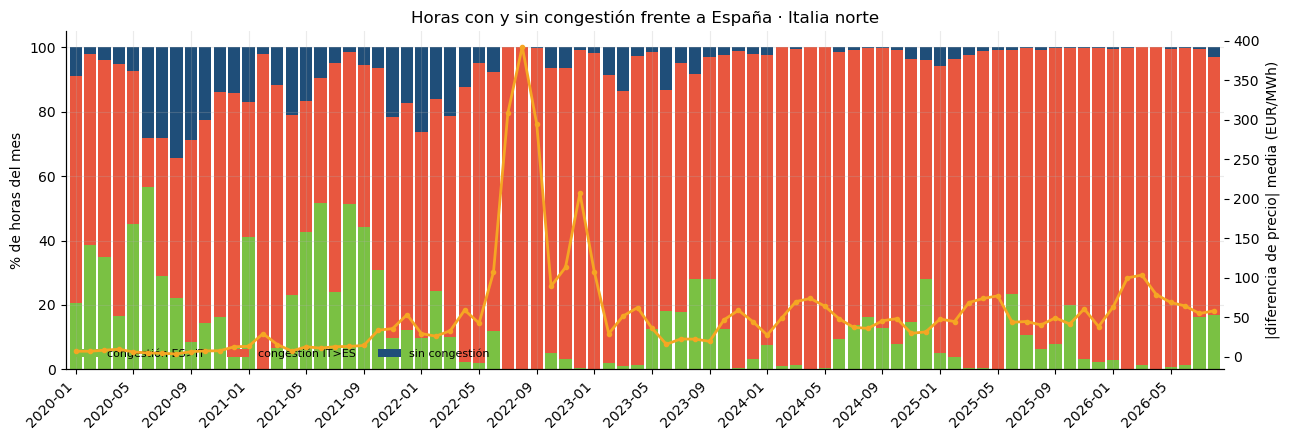


Italia norte:


estado,congestión ES>IT,congestión IT>ES,sin congestión,|dif| media
anio,,,,
2020,25.8,57.8,16.5,6.78
2021,28.3,60.4,11.3,20.66
2022,5.6,85.9,8.5,142.71
2023,10.5,84.3,5.2,43.02
2024,9.5,89.4,1.1,46.40
2025,6.9,91.7,1.3,52.31
2026,4.8,94.7,0.5,73.75


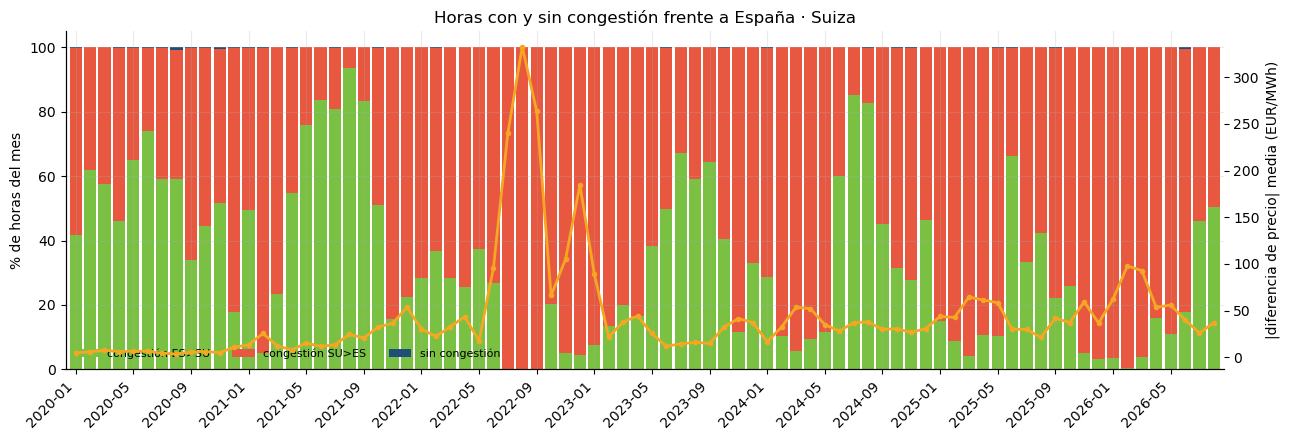


Suiza:


estado,congestión ES>SU,congestión SU>ES,sin congestión,|dif| media
anio,,,,
2020,51.0,48.8,0.2,6.14
2021,53.6,46.4,0.1,22.34
2022,17.6,82.4,0.0,120.36
2023,35.3,64.7,0.0,32.39
2024,37.2,62.7,0.0,34.31
2025,20.6,79.4,0.0,43.98
2026,18.2,81.7,0.1,58.28


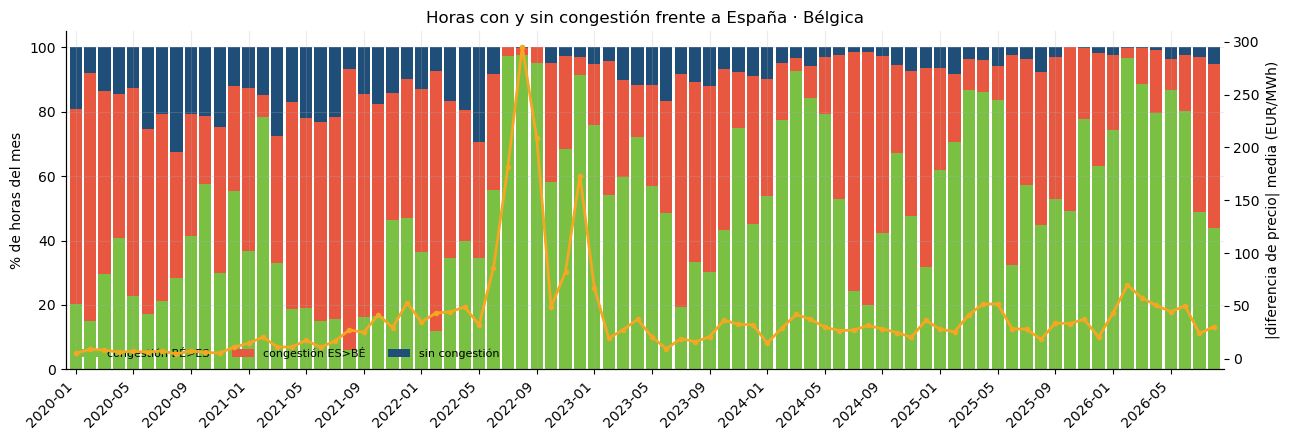


Bélgica:


estado,congestión BÉ>ES,congestión ES>BÉ,sin congestión,|dif| media
anio,,,,
2020,31.7,49.5,18.8,7.05
2021,28.7,54.6,16.8,23.36
2022,60.5,30.8,8.7,107.20
2023,51.0,39.5,9.5,28.42
2024,56.0,39.5,4.4,29.04
2025,63.9,32.3,3.9,33.28
2026,75.2,22.6,2.2,46.32


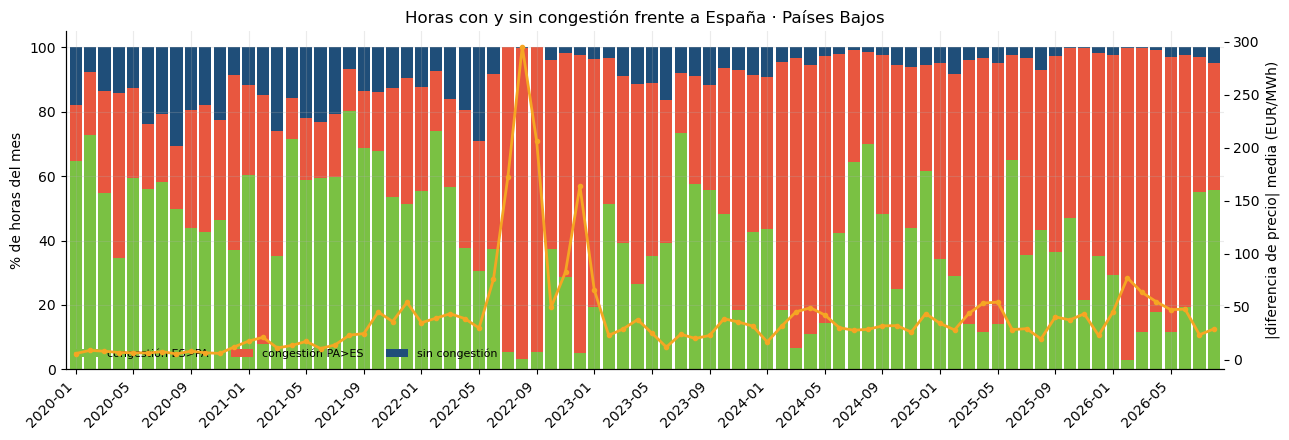


Países Bajos:


estado,congestión ES>PA,congestión PA>ES,sin congestión,|dif| media
anio,,,,
2020,51.7,30.8,17.5,7.57
2021,56.6,27.6,15.8,24.27
2022,31.1,60.5,8.4,103.34
2023,42.3,49.0,8.7,30.76
2024,37.6,58.4,4.1,33.98
2025,32.3,64.2,3.6,36.49
2026,25.1,72.8,2.1,48.74


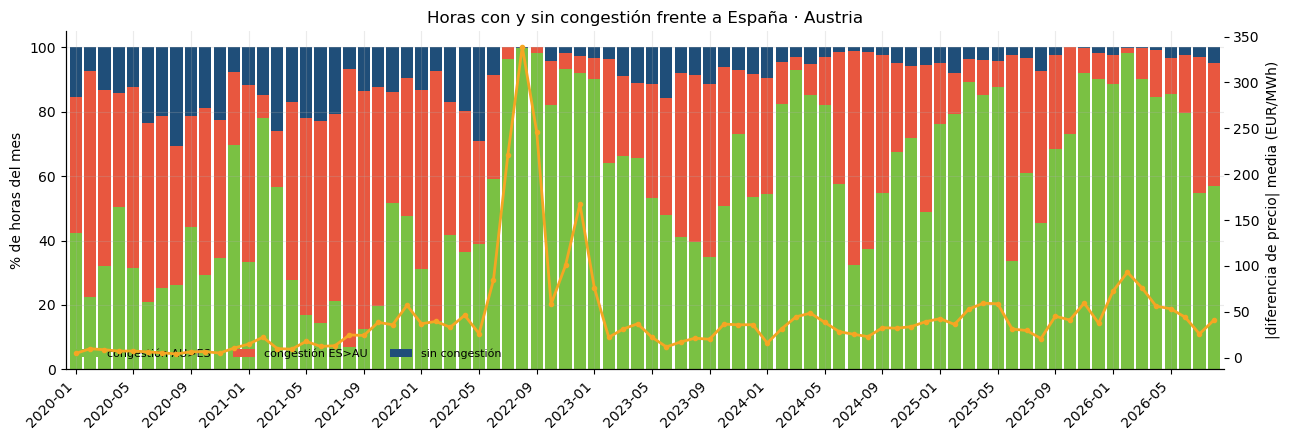


Austria:


estado,congestión AU>ES,congestión ES>AU,sin congestión,|dif| media
anio,,,,
2020,35.8,46.8,17.4,6.82
2021,31.9,52.2,15.9,23.39
2022,65.7,25.7,8.6,117.24
2023,56.7,34.7,8.6,30.78
2024,63.8,32.2,4.0,32.81
2025,73.5,23.0,3.5,42.93
2026,80.1,17.8,2.1,57.80


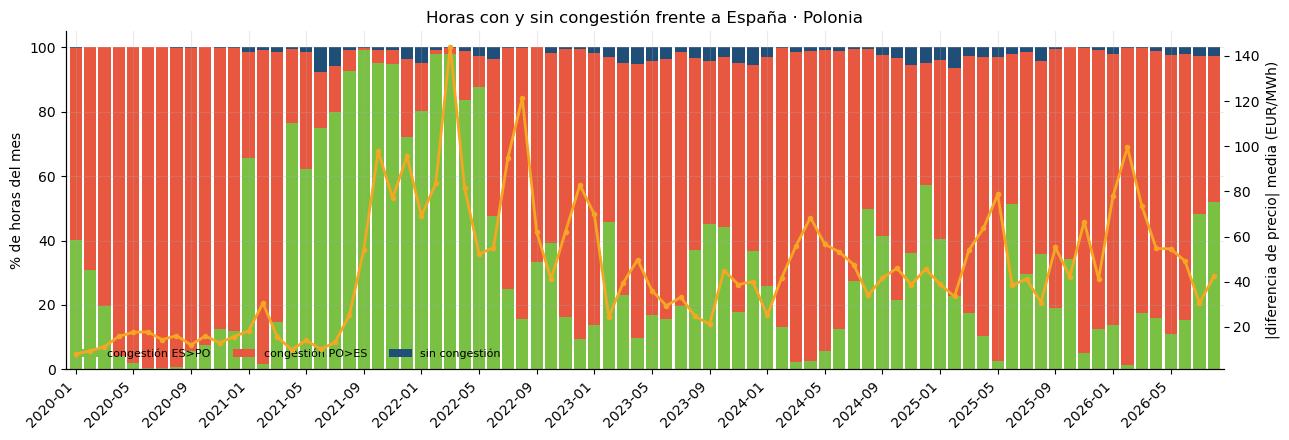


Polonia:


estado,congestión ES>PO,congestión PO>ES,sin congestión,|dif| media
anio,,,,
2020,11.3,88.6,0.1,13.93
2021,69.5,28.4,2.1,38.48
2022,52.6,46.1,1.3,79.25
2023,27.0,69.3,3.7,37.77
2024,24.8,73.2,2.1,46.18
2025,23.4,74.2,2.3,48.76
2026,21.6,76.8,1.6,60.24


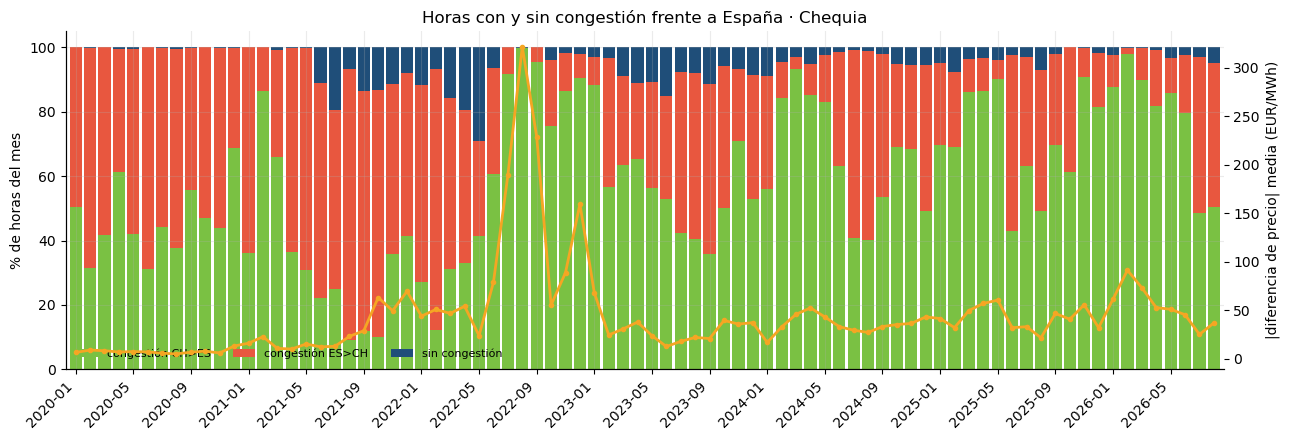


Chequia:


estado,congestión CH>ES,congestión ES>CH,sin congestión,|dif| media
anio,,,,
2020,46.3,53.5,0.2,7.69
2021,33.9,59.0,7.1,28.11
2022,62.4,29.5,8.1,112.40
2023,56.2,35.4,8.3,31.18
2024,65.4,30.8,3.8,35.88
2025,71.7,25.1,3.3,42.08
2026,78.0,19.9,2.1,54.76


In [20]:
UMBRAL_CONV = 0.01   # EUR/MWh: por debajo de esto se considera precio convergido

if SPOT and VECINOS:
    for pais, col in VECINOS.items():
        d = df[["anio", "mes_p", SPOT, col]].dropna().rename(columns={SPOT: "ES", col: pais})
        if d.empty:
            print(f"{pais}: sin horas solapadas"); continue
        d["dif"] = d["ES"] - d[pais]
        d["estado"] = np.select(
            [d["dif"].abs() <= UMBRAL_CONV, d["dif"] > UMBRAL_CONV],
            ["sin congestión", f"congestión ES>{pais[:2].upper()}"],
            default=f"congestión {pais[:2].upper()}>ES")

        mensual = pd.crosstab(d["mes_p"], d["estado"], normalize="index") * 100
        difabs = d.groupby("mes_p")["dif"].apply(lambda s: s.abs().mean())

        fig, ax = plt.subplots(figsize=(13, 4.5))
        mensual.plot(kind="bar", stacked=True, ax=ax, width=0.85,
                     color=["#7ac143", "#e8573f", "#1f4e79"][:mensual.shape[1]])
        ax2 = ax.twinx()
        ax2.plot(range(len(difabs)), difabs.values, color="#f5a623", lw=2, marker="o", ms=3)
        ax2.set_ylabel("|diferencia de precio| media (EUR/MWh)"); ax2.grid(False)
        ax.set_ylabel("% de horas del mes"); ax.set_xlabel("")
        ax.set_title(f"Horas con y sin congestión frente a España · {pais}")
        ax.legend(frameon=False, fontsize=8, ncol=3, loc="lower left")
        paso = max(1, len(mensual) // 20)
        ax.set_xticks(range(0, len(mensual), paso),
                      [str(i) for i in mensual.index[::paso]], rotation=45, ha="right")
        plt.tight_layout(); plt.show()

        anual = pd.crosstab(d["anio"], d["estado"], normalize="index").mul(100).round(1)
        anual["|dif| media"] = d.groupby("anio")["dif"].apply(lambda s: s.abs().mean()).round(2)
        print(f"\n{pais}:")
        display(anual)

**Cómo leer el resultado con Portugal.** Si el porcentaje de horas sin congestión es muy alto
y estable, tratar España y Portugal como una sola zona de precio está justificado con datos y se
puede decir así en la memoria. Si baja con los años, es una limitación del planteamiento que
conviene declarar antes de que la pregunte el tribunal.

**Con Francia** la lectura es otra: cuantas más horas de congestión, más independiente es el
precio español del francés — y menos información aportaría el precio francés aunque estuviera
disponible, que no lo está.

---
## M.5 · Generación renovable frente al precio

**Contexto.** La figura clásica de REE: barras apiladas de eólica, solar e hidráulica con el
precio superpuesto. La relación inversa es evidente, pero conviene cuantificarla y no dejarla en
la impresión visual.

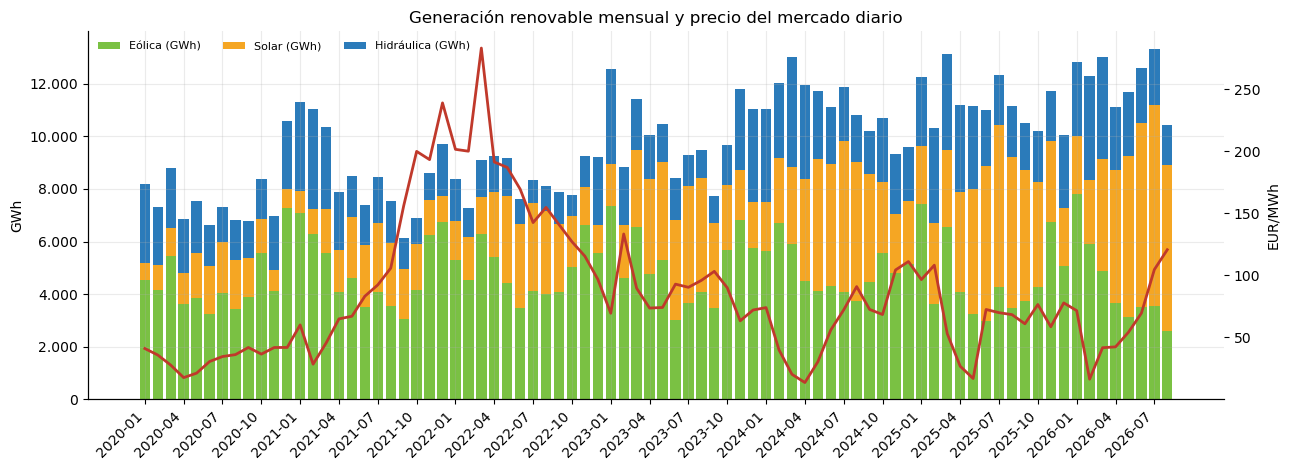

Correlación mensual renovable-precio: -0.3028


In [21]:
if falta("M.5", precio=SPOT, eolica=EOL, solar=FV):
    pass
else:
    cols_ren = {"Eólica": EOL, "Solar": FV}
    if HID:
        cols_ren["Hidráulica"] = HID
    m = df.groupby("mes_p").agg(
        **{k: (v, "sum") for k, v in cols_ren.items()}, precio=(SPOT, "mean"))
    for k in cols_ren:
        m[k] = m[k] / 1000     # GWh

    fig, ax = plt.subplots(figsize=(13, 4.8))
    abajo = np.zeros(len(m))
    colores = {"Eólica": "#7ac143", "Solar": "#f5a623", "Hidráulica": "#2b7bba"}
    for k in cols_ren:
        ax.bar(range(len(m)), m[k], bottom=abajo, label=f"{k} (GWh)", color=colores.get(k), width=0.8)
        abajo += m[k].values
    ax2 = ax.twinx()
    ax2.plot(range(len(m)), m["precio"], color="#c0392b", lw=2, label="precio (EUR/MWh)")
    ax2.set_ylabel("EUR/MWh"); ax2.grid(False)
    ax.set_ylabel("GWh"); ax.yaxis.set_major_formatter(MILES)
    paso = max(1, len(m) // 24)
    ax.set_xticks(range(0, len(m), paso), [str(i) for i in m.index[::paso]], rotation=45, ha="right")
    ax.set_title("Generación renovable mensual y precio del mercado diario")
    ax.legend(frameon=False, ncol=3, fontsize=8, loc="upper left")
    plt.tight_layout(); plt.show()

    print(f"Correlación mensual renovable-precio: "
          f"{m[list(cols_ren)].sum(axis=1).corr(m['precio']):+.4f}")

## M.6 · Porcentaje de renovable frente al precio

**Contexto.** La versión normalizada de la anterior, y la más informativa: lo que hunde el
precio no son los GWh renovables en términos absolutos sino **la fracción de la demanda que
cubren**.

**Consecuencia (feature).** La versión de esta variable construida sólo con previsiones sí es
utilizable a las 12:00 de D. Aquí se mide con datos reales para cuantificar la relación; en el
modelo entra la prevista.

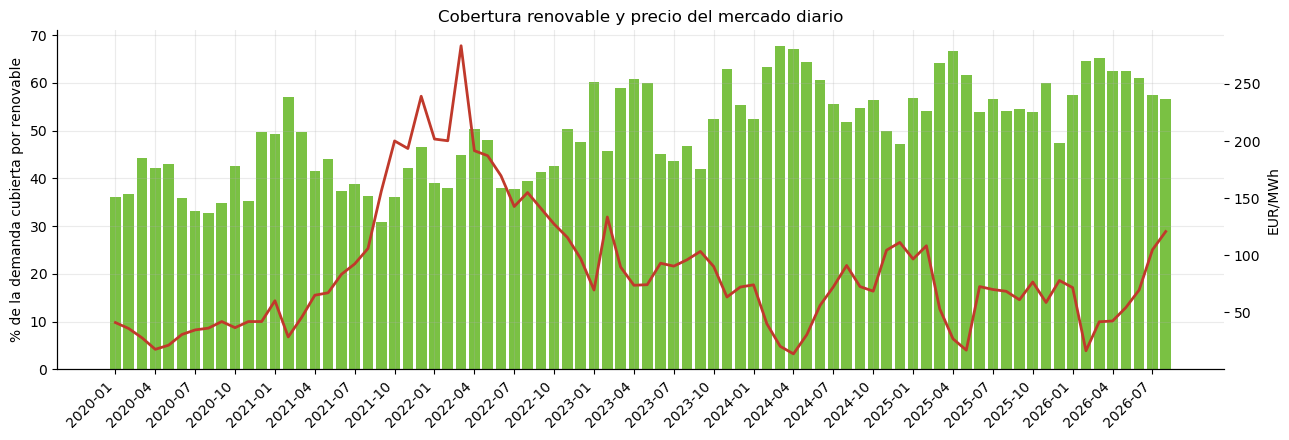

Correlación % renovable vs precio: -0.3621


,horas,precio_medio,pct_precio_cero_o_neg
pct,,,
<20%,12235,114.10,0.01
20-40%,20933,100.42,0.40
40-60%,14337,78.84,2.07
60-80%,8757,39.87,16.95
>80%,1981,12.26,34.98


La última columna es la que importa para el BESS: cuánto sube la probabilidad de precio nulo o negativo conforme sube la penetración renovable horaria.


In [22]:
if SPOT and EOL and FV and DEM:
    m2 = df.groupby("mes_p").agg(ren=(EOL, "sum"), fv=(FV, "sum"), dem=(DEM, "sum"), precio=(SPOT, "mean"))
    if HID:
        m2["hid"] = df.groupby("mes_p")[HID].sum()
    m2["pct_ren"] = (m2["ren"] + m2["fv"] + m2.get("hid", 0)) / m2["dem"] * 100

    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.bar(range(len(m2)), m2["pct_ren"], color="#7ac143", width=0.8, label="% renovable")
    ax2 = ax.twinx()
    ax2.plot(range(len(m2)), m2["precio"], color="#c0392b", lw=2, label="precio ES")
    ax2.set_ylabel("EUR/MWh"); ax2.grid(False)
    ax.set_ylabel("% de la demanda cubierta por renovable")
    paso = max(1, len(m2) // 24)
    ax.set_xticks(range(0, len(m2), paso), [str(i) for i in m2.index[::paso]], rotation=45, ha="right")
    ax.set_title("Cobertura renovable y precio del mercado diario")
    plt.tight_layout(); plt.show()

    print(f"Correlación % renovable vs precio: {m2['pct_ren'].corr(m2['precio']):+.4f}")

    # A nivel horario, que es donde el modelo trabaja de verdad.
    h = df[[SPOT, DEM, EOL, FV]].dropna().copy()
    h["pct"] = (h[EOL] + h[FV]) / h[DEM] * 100
    tramos = pd.cut(h["pct"], [0, 20, 40, 60, 80, 200],
                    labels=["<20%", "20-40%", "40-60%", "60-80%", ">80%"])
    resumen = h.groupby(tramos, observed=True)[SPOT].agg(
        horas="size", precio_medio="mean",
        pct_precio_cero_o_neg=lambda s: (s <= 0).mean() * 100).round(2)
    display(resumen)
    print("La última columna es la que importa para el BESS: cuánto sube la probabilidad de "
          "precio nulo o negativo conforme sube la penetración renovable horaria.")

---
## M.7 · Picos y valles por hora y día de la semana

**Contexto.** Dónde caen los máximos y los mínimos, tanto de demanda como de precio, y cómo se
desplazan. Es la información que necesita el optimizador de la batería: **cuándo cargar y cuándo
descargar** depende de que esos momentos sean estables y predecibles.

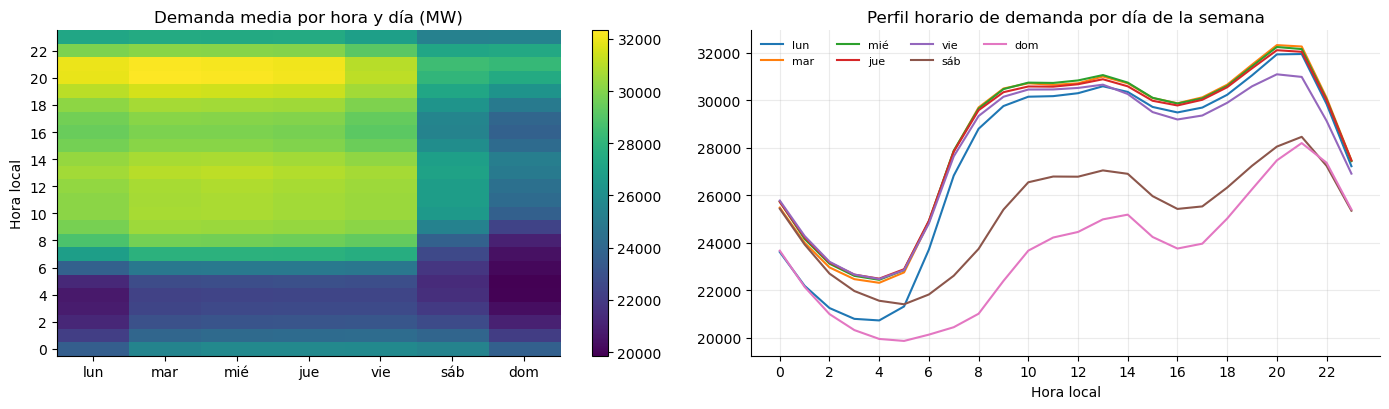

,hora del máximo de demanda,hora del mínimo de demanda
anio,,
2020,13,4
2021,20,4
2022,20,4
2023,20,4
2024,21,4
2025,21,4
2026,20,4


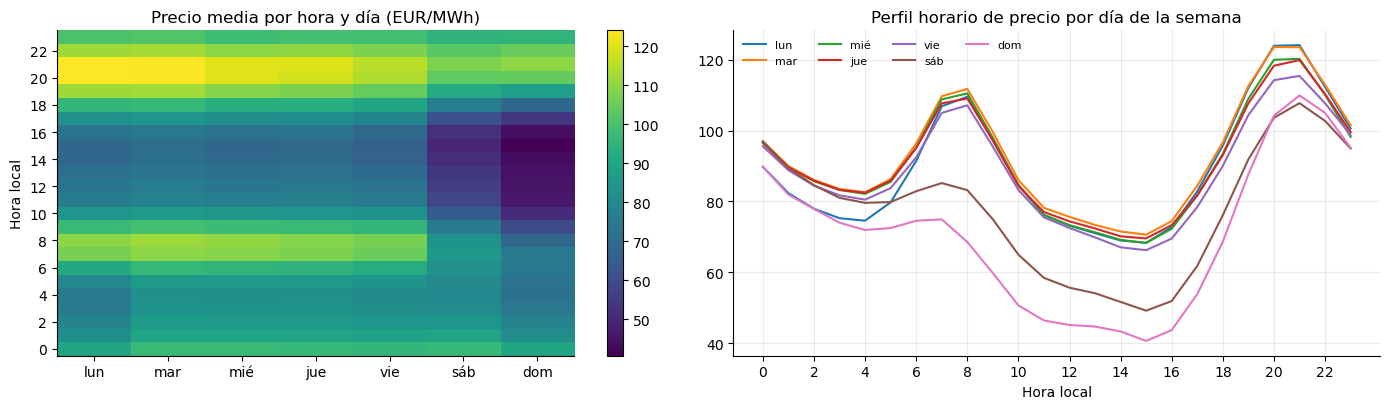

,hora del máximo de precio,hora del mínimo de precio
anio,,
2020,20,4
2021,20,4
2022,21,15
2023,20,15
2024,21,15
2025,21,15
2026,21,13


In [23]:
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]

for etiqueta, col, unidad in [("Demanda", DEM, "MW"), ("Precio", SPOT, "EUR/MWh")]:
    if not col:
        continue
    piv = df.pivot_table(index="hora", columns="dow", values=col, aggfunc="mean")
    piv.columns = DIAS

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
    im = axes[0].imshow(piv.values, aspect="auto", origin="lower", cmap="viridis")
    axes[0].set_xticks(range(7), DIAS); axes[0].set_yticks(range(0, 24, 2))
    axes[0].set_ylabel("Hora local"); axes[0].grid(False)
    axes[0].set_title(f"{etiqueta} media por hora y día ({unidad})")
    fig.colorbar(im, ax=axes[0])

    piv.plot(ax=axes[1])
    axes[1].set_xlabel("Hora local"); axes[1].set_xticks(range(0, 24, 2))
    axes[1].set_title(f"Perfil horario de {etiqueta.lower()} por día de la semana")
    axes[1].legend(frameon=False, ncol=4, fontsize=8)
    plt.tight_layout(); plt.show()

    # idxmax/idxmin devuelven NaN en los días donde la columna es toda nula
    # (bordes del rango, o series que no cubren todo el calendario). Hay que
    # descartar esos días antes de indexar, o .loc falla con 'nan not in index'.
    sub = df[["dia", "anio", "hora", col]].dropna(subset=[col])
    idx_max = sub.groupby("dia")[col].idxmax().dropna()
    idx_min = sub.groupby("dia")[col].idxmin().dropna()

    horas_pico = sub.loc[idx_max].groupby("anio")["hora"].agg(lambda s: s.mode().iat[0])
    horas_valle = sub.loc[idx_min].groupby("anio")["hora"].agg(lambda s: s.mode().iat[0])
    display(pd.DataFrame({f"hora del máximo de {etiqueta.lower()}": horas_pico,
                          f"hora del mínimo de {etiqueta.lower()}": horas_valle}))

**Consecuencia.** Si la hora del mínimo de precio se desplaza hacia el mediodía año a año
mientras la del máximo se queda en la tarde-noche, la ventana de arbitraje del BESS se ensancha
y cambia de posición. Un optimizador calibrado sobre el histórico completo estaría cargando a la
hora equivocada.

## M.8 · Evolución de los precios máximos y mínimos diarios

**Contexto.** La banda diaria máximo-mínimo, que es literalmente el ingreso potencial del
arbitraje. En el informe de REE se superponen dos años; aquí tiene más sentido la serie completa
con los regímenes marcados.

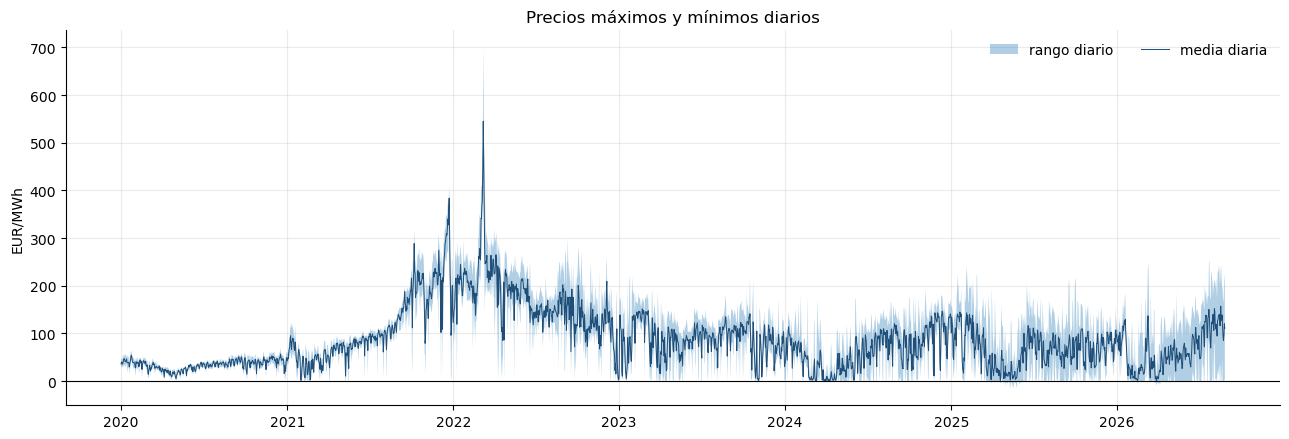

,min_del_año,max_del_año,banda_media,banda_p90,dias_con_min_negativo
dia,,,,,
2020,1.0,68.9,16.9,26.0,0
2021,0.0,409.0,49.6,91.0,0
2022,0.0,700.0,94.4,148.7,0
2023,0.0,220.0,73.3,119.5,0
2024,-2.0,193.0,71.3,117.1,46
2025,-15.0,240.0,98.4,142.7,89
2026,-9.8,255.2,114.0,190.7,108



'banda_media' es el techo teórico del arbitraje por día y por MWh de batería. 'dias_con_min_negativo' cuenta los días en que cobraron por consumir.


In [24]:
if not SPOT:
    print("OMITIDO -- falta el precio")
else:
    d = df.groupby("dia")[SPOT].agg(["min", "max", "mean"]).dropna()
    d.index = pd.to_datetime(d.index)
    d["banda"] = d["max"] - d["min"]

    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.fill_between(d.index, d["min"], d["max"], alpha=0.35, lw=0, label="rango diario")
    ax.plot(d.index, d["mean"], lw=0.7, color="#1f4e79", label="media diaria")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("EUR/MWh"); ax.set_title("Precios máximos y mínimos diarios")
    ax.legend(frameon=False, ncol=2)
    plt.tight_layout(); plt.show()

    anual = d.groupby(d.index.year).agg(
        min_del_año=("min", "min"), max_del_año=("max", "max"),
        banda_media=("banda", "mean"), banda_p90=("banda", lambda s: s.quantile(0.9)),
        dias_con_min_negativo=("min", lambda s: (s < 0).sum())).round(1)
    display(anual)
    print("\n'banda_media' es el techo teórico del arbitraje por día y por MWh de batería. "
          "'dias_con_min_negativo' cuenta los días en que cobraron por consumir.")

---
## M.9 · PDBC frente a PBF: cuánto pesan los bilaterales

**Contexto.** El PBF es el programa base tras la casación, y el PDBC es el programa diario
viable. La diferencia entre ambos recoge, entre otras cosas, la **contratación bilateral**: la
energía comprometida fuera del mercado diario, que no pasa por la casación pero sí ocupa red.

**Por qué interesa al TFM.** Si el volumen bilateral es grande y variable, una parte de la
generación no está respondiendo a la señal de precio, y eso limita cuánto puede explicar un
modelo que solo mire el mercado diario. Si es pequeño y estable, se puede ignorar con
tranquilidad — y esa también es una conclusión que conviene documentar.

**Frontera de fuga:** ambos programas son de D+1 y salen de la misma casación que el precio. Uso
descriptivo, o con lag.

In [25]:
RUTAS = {"pdbc": BRONZE_DIR / "esios_pdbc_gen_raw.parquet",
         "pbf_gen": BRONZE_DIR / "esios_pbf_gen_raw.parquet",
         "pbf_bilateral": BRONZE_DIR / "esios_pbf_bilateral_raw.parquet"}
P = {}
for k, ruta in RUTAS.items():
    if ruta.exists():
        P[k] = pd.read_parquet(ruta)
        print(f"OK  {k:14s} {P[k].shape}")
    else:
        print(f"--  {k:14s} falta {ruta.name}")

if len(P) < 2:
    OMITIDOS.append("M.9: faltan los parquets de PDBC/PBF")
    print("\nOMITIDO -- añadir esios_pdbc_gen y esios_pbf_* a bronze_config y extraerlos.")

--  pdbc           falta esios_pdbc_gen_raw.parquet
--  pbf_gen        falta esios_pbf_gen_raw.parquet
--  pbf_bilateral  falta esios_pbf_bilateral_raw.parquet

OMITIDO -- añadir esios_pdbc_gen y esios_pbf_* a bronze_config y extraerlos.


In [26]:
def normaliza(d):
    ts = pick(d, "ts_utc", "datetime", "datetime_utc", "ts")
    d = d.copy()
    d["ts_utc"] = pd.to_datetime(d[ts], utc=True)
    return d

if len(P) >= 2 and "pdbc" in P and "pbf_gen" in P:
    a, b = normaliza(P["pdbc"]), normaliza(P["pbf_gen"])
    comunes = [c for c in a.columns if c in b.columns and c != "ts_utc"
               and pd.api.types.is_numeric_dtype(a[c])]
    print(f"{len(comunes)} columnas comparables entre PDBC y PBF: {comunes[:10]}")

    m = a[["ts_utc"] + comunes].merge(b[["ts_utc"] + comunes], on="ts_utc",
                                      suffixes=("_pdbc", "_pbf"), validate="one_to_one")
    filas = []
    for c in comunes:
        dif = m[f"{c}_pdbc"] - m[f"{c}_pbf"]
        filas.append({"tecnología": c, "media PDBC": m[f"{c}_pdbc"].mean(),
                      "media PBF": m[f"{c}_pbf"].mean(), "dif. media": dif.mean(),
                      "dif. |media|": dif.abs().mean(),
                      "corr": m[f"{c}_pdbc"].corr(m[f"{c}_pbf"])})
    comparativa = pd.DataFrame(filas).set_index("tecnología").round(2)
    display(comparativa.sort_values("dif. |media|", ascending=False))
    print("\nUna correlación cercana a 1 con diferencia media casi nula significa que PDBC y PBF "
          "dicen prácticamente lo mismo: no aportan dos features, aportan una.")

In [27]:
if "pbf_bilateral" in P:
    bil = normaliza(P["pbf_bilateral"])
    num = [c for c in bil.columns if pd.api.types.is_numeric_dtype(bil[c])]
    bil["total"] = bil[num].sum(axis=1)
    bil["mes_p"] = bil["ts_utc"].dt.tz_convert(TZ).dt.to_period("M")

    if DEM:
        d = df[["ts_utc", DEM]].merge(bil[["ts_utc", "total"]], on="ts_utc", validate="one_to_one")
        d["peso_pct"] = d["total"] / d[DEM] * 100
        d["mes_p"] = d["ts_utc"].dt.tz_convert(TZ).dt.to_period("M")
        ax = d.groupby("mes_p")["peso_pct"].mean().plot(
            figsize=(12, 4), title="Peso de la contratación bilateral sobre la demanda")
        ax.set_ylabel("% de la demanda"); ax.set_xlabel("")
        plt.tight_layout(); plt.show()
        print(d["peso_pct"].describe().round(2).to_string())
        print("\nSi el peso es bajo y estable, la contratación bilateral no distorsiona la señal "
              "de precio y puede quedar fuera del modelo. Si es alto o crece, hay una parte del "
              "sistema que no responde al mercado diario, y conviene decirlo como limitación.")

---
## M.10 · Estructura de generación en la casación, precio y gas

**Contexto.** La figura que cierra el círculo del informe de REE: el reparto porcentual del mix
mes a mes, con el precio del mercado diario y el del gas superpuestos. Es la representación
visual del orden de mérito.

**Consecuencia.** Cuando el precio sigue al gas mientras el ciclo combinado tiene peso en el
mix, y se despega cuando la renovable lo desplaza, queda ilustrado por qué el modelo necesita
tanto el gas como la penetración renovable prevista: ninguna de las dos explica el precio por sí
sola.

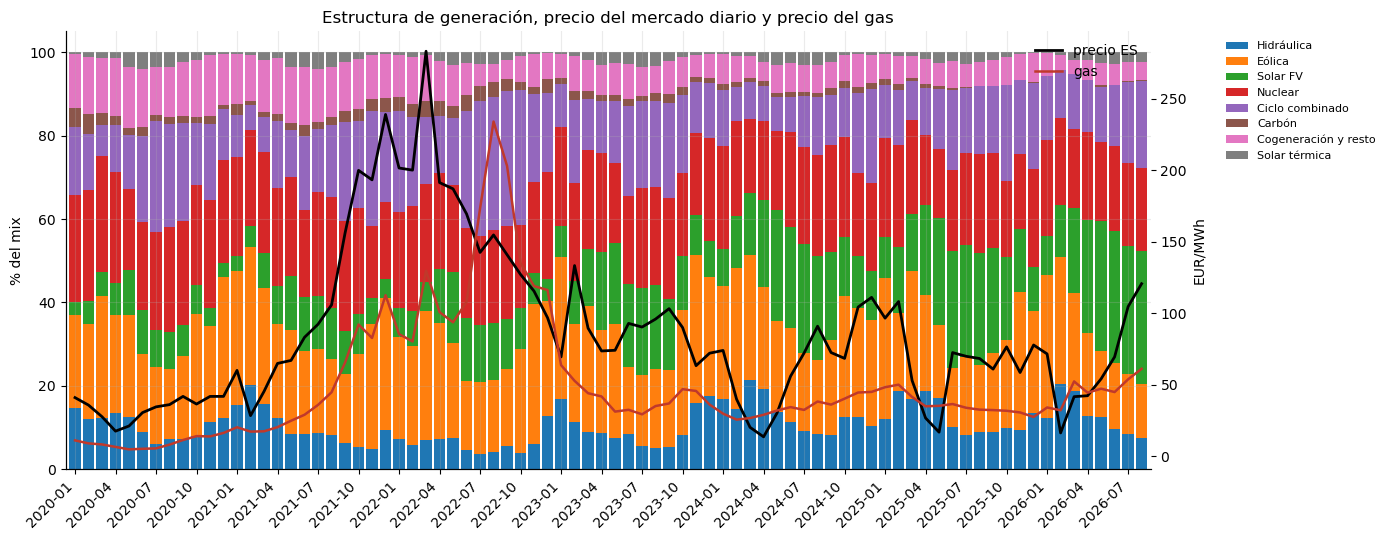

Correlación precio-gas con CCGT por encima de la mediana: +0.6526
Correlación precio-gas con CCGT por debajo de la mediana: +0.7363

Si la primera es claramente mayor, queda demostrado con datos propios que el gas marca el precio sólo cuando el ciclo combinado está en el margen. Es un argumento para una feature de interacción, no para meter el gas solo.


In [28]:
cols_mix = {k: v for k, v in {
    "Hidráulica": HID, "Eólica": EOL, "Solar FV": FV,
    "Nuclear": pick(df, "entsoe_nuclear_mw", "esios_gen_ree_gnuclear_mw"),
    "Ciclo combinado": pick(df, "esios_gen_ree_gccgas_mw"),
    "Carbón": pick(df, "esios_gen_ree_gcoal_mw", "entsoe_coal_mw"),
    "Cogeneración y resto": pick(df, "esios_gen_ree_gotherthermal_mw"),
    "Solar térmica": pick(df, "esios_gen_ree_gsolter_mw"),
}.items() if v}

if not SPOT or len(cols_mix) < 4:
    OMITIDOS.append("M.10: falta el precio o el mix está incompleto")
    print("OMITIDO --", {"precio": SPOT, "tecnologías": list(cols_mix)})
else:
    mix = df.groupby("mes_p").agg(**{k: (v, "sum") for k, v in cols_mix.items()})
    mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100
    precio_m = df.groupby("mes_p")[SPOT].mean()
    gas_m = df.groupby("mes_p")[GAS].mean() if GAS else None

    fig, ax = plt.subplots(figsize=(14, 5.5))
    mix_pct.plot(kind="bar", stacked=True, ax=ax, width=0.85, legend=False)
    ax2 = ax.twinx()
    ax2.plot(range(len(precio_m)), precio_m.values, color="black", lw=2, label="precio ES")
    if gas_m is not None:
        ax2.plot(range(len(gas_m)), gas_m.values, color="#c0392b", lw=1.8, label="gas")
    ax2.set_ylabel("EUR/MWh"); ax2.grid(False)
    ax2.legend(frameon=False, loc="upper right")
    ax.set_ylabel("% del mix"); ax.set_xlabel("")
    paso = max(1, len(mix_pct) // 24)
    ax.set_xticks(range(0, len(mix_pct), paso),
                  [str(i) for i in mix_pct.index[::paso]], rotation=45, ha="right")
    ax.set_title("Estructura de generación, precio del mercado diario y precio del gas")
    ax.legend(bbox_to_anchor=(1.06, 1), loc="upper left", frameon=False, fontsize=8)
    plt.tight_layout(); plt.show()

    if gas_m is not None:
        ccgt = mix_pct.get("Ciclo combinado")
        if ccgt is not None:
            corr_alta = precio_m[ccgt > ccgt.median()].corr(gas_m[ccgt > ccgt.median()])
            corr_baja = precio_m[ccgt <= ccgt.median()].corr(gas_m[ccgt <= ccgt.median()])
            print(f"Correlación precio-gas con CCGT por encima de la mediana: {corr_alta:+.4f}")
            print(f"Correlación precio-gas con CCGT por debajo de la mediana: {corr_baja:+.4f}")
            print("\nSi la primera es claramente mayor, queda demostrado con datos propios que "
                  "el gas marca el precio sólo cuando el ciclo combinado está en el margen. "
                  "Es un argumento para una feature de interacción, no para meter el gas solo.")

---
## Cierre

In [29]:
print("BLOQUES OMITIDOS")
print("=" * 60)
if OMITIDOS:
    for o in dict.fromkeys(OMITIDOS):
        print(" -", o)
else:
    print("Ninguno: el notebook corrió completo.")

print()
for linea in [
    "",
    "QUÉ SE LLEVA DE AQUÍ EL RESTO DEL TFM",
    "=" * 60,
    "",
    "  M.4  Congestión con Portugal -> decide si el perímetro peninsular es una sola zona,",
    "       que es un supuesto que el TFM ya está asumiendo sin haberlo verificado.",
    "  M.6  Precio por tramo de penetración renovable -> cuantifica la probabilidad de",
    "       precio cero o negativo, que es lo que gobierna el arbitraje del BESS.",
    "  M.7  Hora del máximo y del mínimo por año -> si se desplazan, un optimizador",
    "       calibrado sobre el histórico completo carga a la hora equivocada.",
    "  M.9  Peso de los bilaterales -> o se ignoran con criterio, o se declara la limitación.",
    "  M.10 Correlación precio-gas condicionada al peso del CCGT -> argumento para una",
    "       feature de interacción en vez de meter el gas como término suelto.",
    "",
    "Ninguna de estas figuras es una feature. Todas son decisiones de modelado justificadas",
    "con evidencia propia, que es lo que distingue un capítulo de EDA de una galería.",
]:
    print(linea)

BLOQUES OMITIDOS
 - M.9: faltan los parquets de PDBC/PBF


QUÉ SE LLEVA DE AQUÍ EL RESTO DEL TFM

  M.4  Congestión con Portugal -> decide si el perímetro peninsular es una sola zona,
       que es un supuesto que el TFM ya está asumiendo sin haberlo verificado.
  M.6  Precio por tramo de penetración renovable -> cuantifica la probabilidad de
       precio cero o negativo, que es lo que gobierna el arbitraje del BESS.
  M.7  Hora del máximo y del mínimo por año -> si se desplazan, un optimizador
       calibrado sobre el histórico completo carga a la hora equivocada.
  M.9  Peso de los bilaterales -> o se ignoran con criterio, o se declara la limitación.
  M.10 Correlación precio-gas condicionada al peso del CCGT -> argumento para una
       feature de interacción en vez de meter el gas como término suelto.

Ninguna de estas figuras es una feature. Todas son decisiones de modelado justificadas
con evidencia propia, que es lo que distingue un capítulo de EDA de una galería.
